# 03 - Baseline Extra Trees

Treina o `ExtraTreesRegressor` (split 80/20 `random_state=42`, GridSearchCV 10-fold) sobre as 10 features e reproduz as metricas e figuras do paper (parity, histograma, SHAP).

Logica em `src`; o notebook orquestra e visualiza.

In [1]:
import logging
from pathlib import Path

import pandas as pd

from baseline import run_baseline
from plots import importance_frame, plot_dG_hist, plot_parity, plot_shap_bar
from storage import load_features_frame

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())

In [2]:
df = load_features_frame(ROOT / "data" / "metadata.sqlite")
print(f"linhas com features: {len(df)}")
df.head()

linhas com features: 5860


,id,site_type,composition,delta_G_H,phi,L_bond,Np0,Nd1,Out_e0,R0,First_IE0,CN,Out_e1,psi1
0,UmVhY3Rpb246MzM5NjQ1,bridge,Os12,-0.168579,307.272727,1.837107,24.0,26.000000,8.0,130.0,8.43823,10.0,8.000000,2.200000
1,UmVhY3Rpb246MzM5NjQ2,hollow,Os12,-0.258513,307.272727,1.926000,24.0,26.000000,8.0,130.0,8.43823,10.0,8.000000,2.200000
2,UmVhY3Rpb246MzM5NjQ3,hollow,Os12,-0.228760,307.272727,1.922648,24.0,26.000000,8.0,130.0,8.43823,10.0,8.000000,2.200000
3,UmVhY3Rpb246MzM5NjQ4,top,Os12,-0.065030,307.272727,1.658070,24.0,26.000000,8.0,130.0,8.43823,10.0,8.000000,2.200000
4,UmVhY3Rpb246MzM5ODgy,hollow,Bi3Pt9,-0.136341,382.272727,1.844060,24.0,29.395937,10.0,135.0,8.95883,10.0,7.578583,2.074699


In [3]:
result = run_baseline(df)
print("best params:", result.best_params)
pd.DataFrame({"train": result.metrics_train, "test": result.metrics_test}).round(4)

INFO her_gnn.baseline: train=4688 test=1172 features=10


INFO her_gnn.baseline: best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300} (cv R2=0.9237)


INFO her_gnn.baseline: test metrics: {'R2': 0.9341, 'MAE': 0.0955, 'MSE': 0.0259, 'RMSE': 0.1609}


best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


,train,test
R2,0.9987,0.9341
MAE,0.0123,0.0955
MSE,0.0005,0.0259
RMSE,0.0216,0.1609


## Fig. 3b - distribuicao de delta_G_H

INFO her_gnn.plots: saved fig3b_dG_hist.{png,pdf}


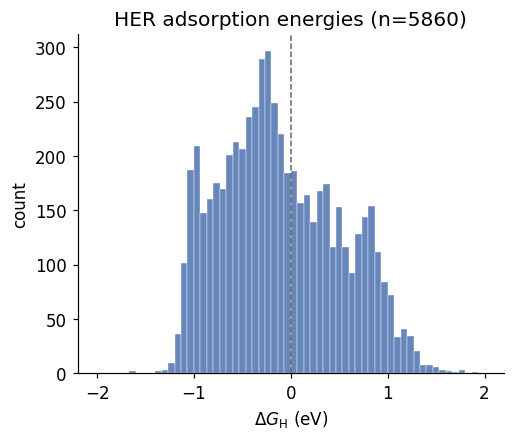

In [4]:
plot_dG_hist(df["delta_G_H"].to_numpy())
import matplotlib.pyplot as plt
plt.show()

## Fig. 4f - parity predito vs DFT

INFO her_gnn.plots: saved fig4f_parity.{png,pdf}


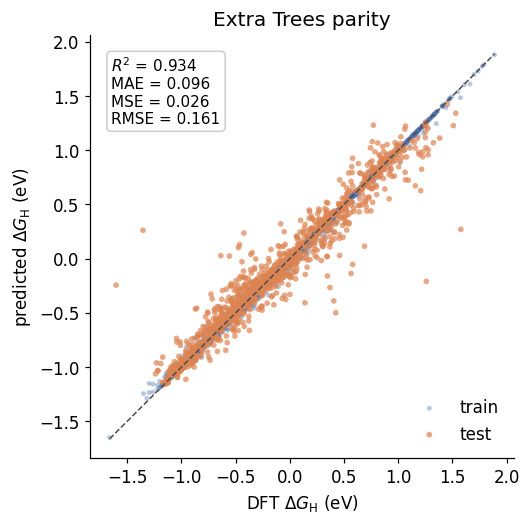

In [5]:
plot_parity(result)
plt.show()

## Fig. 6d - importancia das 10 features (SHAP)

INFO her_gnn.plots: saved fig6d_shap.{png,pdf}


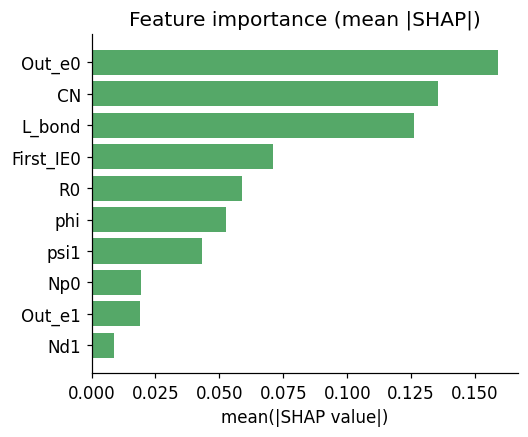

,feature,importance
0,CN,0.230320
1,Out_e0,0.222173
2,L_bond,0.156642
3,First_IE0,0.097715
4,phi,0.085611
5,R0,0.073029
6,psi1,0.043749
7,Np0,0.035934
8,Out_e1,0.034701
9,Nd1,0.020124


In [6]:
plot_shap_bar(result)
plt.show()
importance_frame(result)